# Proyecto de Regresión Supervisada — Estrategia Competitiva (MSE)

Este notebook implementa un flujo **reproducible** y orientado a **generalización** para minimizar MSE:

1. EDA técnico (estructura, faltantes, distribuciones, outliers, correlaciones, multicolinealidad).
2. Preprocesamiento con `Pipeline` + `ColumnTransformer` (sin data leakage).
3. Entrenamiento y optimización de múltiples modelos (baseline y modelos fuertes).
4. Comparación cuantitativa en validación con métrica principal **MSE**.
5. Persistencia del mejor pipeline con `pickle`.
6. Generación de `predicciones.csv` con una sola columna `SalePrice` para el archivo `test_features.csv`.

**Nota del curso:** la decisión final del modelo se basa en menor MSE.

In [14]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

## 1) Carga y revisión inicial de datos

In [15]:
X = pd.read_csv('data/training_features.csv')
y_df = pd.read_csv('data/training_target.csv')

if 'SalePrice' not in y_df.columns:
    raise ValueError("training_target.csv debe contener la columna 'SalePrice'")

y = y_df['SalePrice']

print('Dimensiones X:', X.shape)
print('Dimensiones y:', y.shape)
print('Tipos de variables (top):')
display(X.dtypes.value_counts())

display(X.head(3))
display(y.head(3))

Dimensiones X: (2344, 79)
Dimensiones y: (2344,)
Tipos de variables (top):


object     43
int64      25
float64    11
Name: count, dtype: int64

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,7,5,1976,1976,Gable,CompShg,HdBoard,HdBoard,BrkFace,189.0,TA,TA,CBlock,Gd,TA,No,Unf,0.0,Unf,0.0,1090.0,1090.0,GasA,TA,Y,SBrkr,1370,0,0,1370,0.0,0.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,479.0,TA,TA,Y,0,0,0,0,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Family
1,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,Sev,ClearCr,Norm,Norm,1Fam,2Story,5,5,1967,1967,Flat,Tar&Grv,Plywood,Plywood,NaN,0.0,TA,TA,PConc,TA,Gd,Gd,LwQ,249.0,ALQ,764.0,0.0,1013.0,GasA,TA,Y,SBrkr,1160,966,0,2126,0.0,1.0,2,1,3,1,TA,7,Min2,0,NaN,Attchd,1967.0,Fin,2.0,538.0,TA,TA,Y,486,0,0,0,225,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml
2,90,RL,70.0,9842,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,Duplex,1Story,4,5,1962,1962,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,GasA,TA,Y,SBrkr,1224,0,0,1224,0.0,0.0,2,0,2,2,TA,6,Typ,0,NaN,CarPort,1962.0,Unf,2.0,462.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal


0    152000
1    185000
2    101800
Name: SalePrice, dtype: int64

In [16]:
# ── Mapeos ordinales ──────────────────────────────────────────────────────────
quality_cols = ['Exter Qual', 'Kitchen Qual', 'Bsmt Qual', 'Fireplace Qu',
                'Garage Qual', 'Garage Cond', 'Exter Cond', 'Heating QC', 'Bsmt Cond', 'Pool QC']
quality_map = {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_maps = {
    'Bsmt Exposure':  {'NA': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFin Type 1': {'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFin Type 2': {'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'Garage Finish':  {'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Functional':     {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'Fence':          {'NA': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'Paved Drive':    {'N': 0, 'P': 1, 'Y': 2},
    'Central Air':    {'N': 0, 'Y': 1},
    'Lot Shape':      {'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3},
    'Land Slope':     {'Gtl': 0, 'Mod': 1, 'Sev': 2},
    'Street':         {'Grvl': 0, 'Pave': 1},
}

all_ordinal_cols = quality_cols + list(ordinal_maps.keys())

# ── Columnas con >80% nulos en training → se eliminan ────────────────────────
missing = X.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(X)).sort_values(ascending=False)
cols_to_drop_training = missing_ratio[missing_ratio > 0.80].index.tolist()

# ── Columnas redundantes por alta multicolinealidad ──────────────────────────
redundant_cols = ['Garage Cond']   # ρ= 0.94 con Garage Qual

def preparar_datos(df):
    """Preprocesa features: drop nulos, mapeos ordinales, feature engineering."""
    X = df.copy()

    # 1) Drop columnas >80% nulos (usa la lista de training siempre)
    drop = [c for c in cols_to_drop_training if c in X.columns]
    if drop:
        X = X.drop(columns=drop)

    # 2) Drop columnas redundantes
    drop_red = [c for c in redundant_cols if c in X.columns]
    if drop_red:
        X = X.drop(columns=drop_red)

    # 3) Mapeo ordinal de calidad (Ex/Gd/TA/Fa/Po)
    for col in quality_cols:
        if col in X.columns:
            X[col] = X[col].map(quality_map).fillna(0).astype(int)

    # 4) Mapeo ordinal de otras variables ordenadas
    for col, mapping in ordinal_maps.items():
        if col in X.columns:
            X[col] = X[col].map(mapping).fillna(0).astype(int)

    # ── 5) Feature engineering ────────────────────────────────────────────────

    # Área total habitable (basement + pisos)
    X['Total SF'] = X['Total Bsmt SF'].fillna(0) + X['1st Flr SF'] + X['2nd Flr SF']

    # Total baños
    X['Total Bath'] = (X['Full Bath'] + 0.5 * X['Half Bath']
                       + X['Bsmt Full Bath'].fillna(0) + 0.5 * X['Bsmt Half Bath'].fillna(0))

    # Edad de la casa y de remodelación
    X['House Age'] = X['Yr Sold'] - X['Year Built']
    X['Remod Age'] = X['Yr Sold'] - X['Year Remod/Add']
    X['Is Remodeled'] = (X['Year Built'] != X['Year Remod/Add']).astype(int)

    # Edad del garaje
    if 'Garage Yr Blt' in X.columns:
        X['Garage Age'] = X['Yr Sold'] - X['Garage Yr Blt'].fillna(X['Year Built'])

    # Área total de porch
    porch_cols = ['Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch']
    existing_porch = [c for c in porch_cols if c in X.columns]
    X['Total Porch SF'] = X[existing_porch].sum(axis=1)

    # Flags binarios
    X['Has 2nd Floor'] = (X['2nd Flr SF'] > 0).astype(int)
    X['Has Garage'] = (X.get('Garage Cars', pd.Series(0)) > 0).astype(int)
    X['Has Bsmt'] = (X['Total Bsmt SF'].fillna(0) > 0).astype(int)
    X['Has Fireplace'] = (X.get('Fireplaces', pd.Series(0)) > 0).astype(int)
    X['Has MasVnr'] = (X.get('Mas Vnr Area', pd.Series(0)).fillna(0) > 0).astype(int)

    # ★ Interacciones clave (las más predictivas en datasets tipo Ames)
    X['Qual x GrLivArea'] = X['Overall Qual'] * X['Gr Liv Area']
    X['Qual x TotalSF']   = X['Overall Qual'] * X['Total SF']
    X['Qual x GarageCars'] = X['Overall Qual'] * X.get('Garage Cars', pd.Series(0)).fillna(0)
    X['Qual x TotalBath']  = X['Overall Qual'] * X['Total Bath']
    X['GrLivArea x TotalBath'] = X['Gr Liv Area'] * X['Total Bath']

    # Ratio de área terminada del sótano
    X['Bsmt Fin Ratio'] = X['BsmtFin SF 1'].fillna(0) / (X['Total Bsmt SF'].fillna(0) + 1)

    # Lot Frontage / Lot Area ratio
    X['Lot Frontage Ratio'] = X['Lot Frontage'].fillna(0) / (X['Lot Area'] + 1)

    return X


X = preparar_datos(X)

# ── Clasificar columnas numéricas vs categóricas ─────────────────────────────
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

# Asegurar que ordinals mapeados estén como numéricos
mapped_ordinal_cols = [c for c in all_ordinal_cols if c in X.columns]
num_cols = list(dict.fromkeys(num_cols + mapped_ordinal_cols))
cat_cols = [c for c in cat_cols if c not in mapped_ordinal_cols]

if cols_to_drop_training:
    print(f'Columnas eliminadas (>80% nulos): {cols_to_drop_training}')
print(f'Columnas redundantes eliminadas: {redundant_cols}')
print(f'Variables numéricas: {len(num_cols)}  |  Variables categóricas: {len(cat_cols)}')

# Resumen de faltantes
missing = X.isna().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({'count': missing, 'ratio': missing / len(X)})
print('\nTop faltantes restantes:')
display(missing_table[missing_table['count'] > 0].head(15))
print(f'\nDescripción del target:')
display(y.describe())

Columnas eliminadas (>80% nulos): ['Pool QC', 'Misc Feature', 'Alley']
Columnas redundantes eliminadas: ['Garage Cond']
Variables numéricas: 74  |  Variables categóricas: 20

Top faltantes restantes:


,count,ratio
Mas Vnr Type,1426,0.608362
Lot Frontage,393,0.167662
Garage Yr Blt,122,0.052048
Garage Type,120,0.051195
Mas Vnr Area,19,0.008106
BsmtFin SF 1,1,0.000427
BsmtFin SF 2,1,0.000427
Bsmt Unf SF,1,0.000427
Bsmt Half Bath,1,0.000427
Bsmt Full Bath,1,0.000427



Descripción del target:


count      2344.000000
mean     178582.207765
std       77125.072713
min       12789.000000
25%      129000.000000
50%      160000.000000
75%      210000.000000
max      755000.000000
Name: SalePrice, dtype: float64

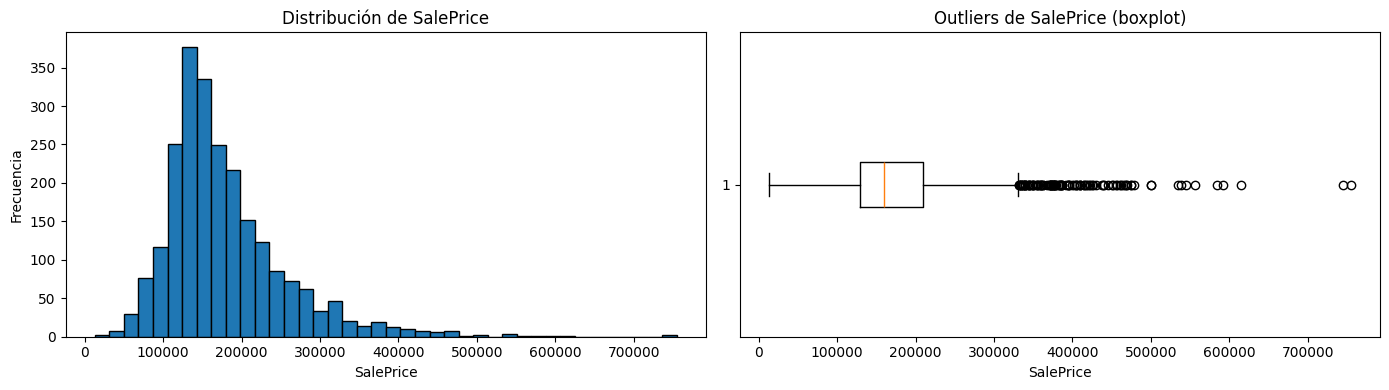

Outliers en target según IQR: 107 (4.56%)


In [17]:
# Distribución de target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y, bins=40, edgecolor='black')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(y, vert=False)
axes[1].set_title('Outliers de SalePrice (boxplot)')
axes[1].set_xlabel('SalePrice')

plt.tight_layout()
plt.show()

# Outliers por criterio IQR solo para el target
q1, q3 = y.quantile(0.25), y.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_target = ((y < lower) | (y > upper)).sum()
print(f'Outliers en target según IQR: {outliers_target} ({outliers_target/len(y):.2%})')

Top correlaciones positivas con SalePrice:


Qual x TotalSF           0.865605
Qual x GrLivArea         0.839856
Qual x TotalBath         0.815353
Qual x GarageCars        0.814391
Overall Qual             0.795298
Total SF                 0.777658
GrLivArea x TotalBath    0.742406
Gr Liv Area              0.698315
Exter Qual               0.685320
Kitchen Qual             0.661169
Garage Cars              0.644304
Total Bath               0.639103
Name: SalePrice, dtype: float64

Top correlaciones negativas con SalePrice:


Bsmt Half Bath       -0.023675
Yr Sold              -0.037686
Is Remodeled         -0.057982
MS SubClass          -0.066351
Overall Cond         -0.104085
Kitchen AbvGr        -0.115860
Enclosed Porch       -0.130722
Lot Frontage Ratio   -0.145250
Fence                -0.155544
Remod Age            -0.520096
Garage Age           -0.530299
House Age            -0.546208
Name: SalePrice, dtype: float64

Pares con correlación >= 0.85: 22


Year Built        House Age                0.999063
Garage Yr Blt     Garage Age               0.998692
Year Remod/Add    Remod Age                0.997998
Fireplace Qu      Has Fireplace            0.951436
Qual x GrLivArea  Qual x TotalSF           0.941953
Total SF          Qual x TotalSF           0.930219
Garage Qual       Has Garage               0.929484
Garage Cars       Qual x GarageCars        0.919870
Gr Liv Area       Qual x GrLivArea         0.917744
Total Bath        Qual x TotalBath         0.916233
2nd Flr SF        Has 2nd Floor            0.907443
Fireplaces        Has Fireplace            0.895818
Garage Cars       Garage Area              0.883871
Gr Liv Area       GrLivArea x TotalBath    0.879225
Total SF          Qual x GrLivArea         0.875612
Qual x TotalBath  GrLivArea x TotalBath    0.868564
Gr Liv Area       Total SF                 0.866624
Qual x GrLivArea  GrLivArea x TotalBath    0.866379
Total Bath        GrLivArea x TotalBath    0.859866
Fireplaces  

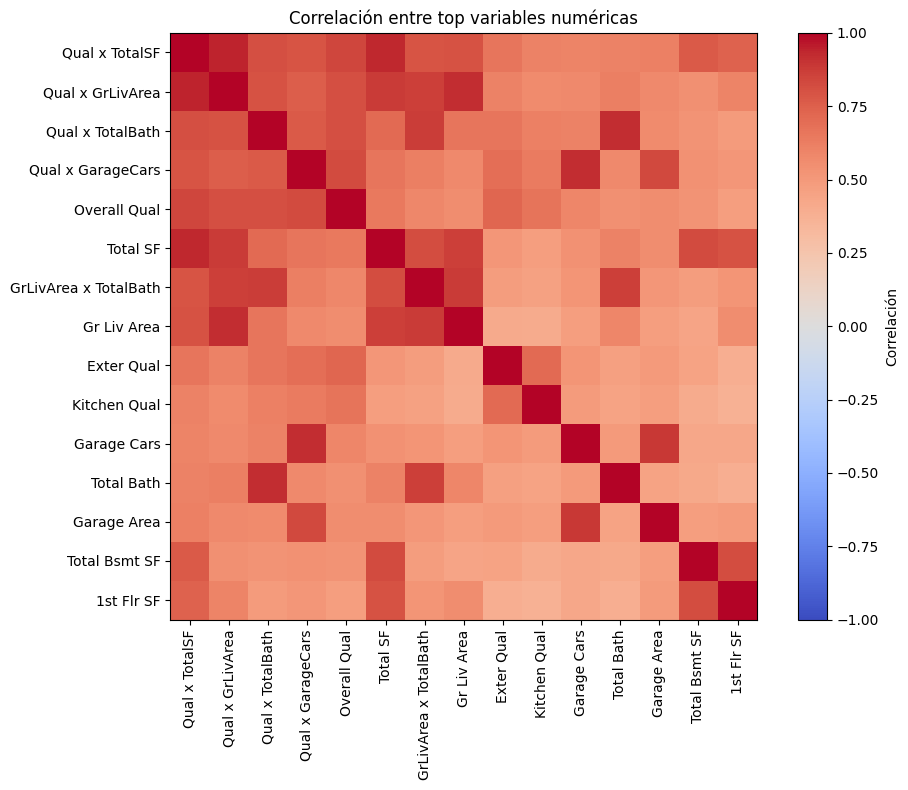

In [18]:
# Correlación con target (solo numéricas)
corr_with_target = X[num_cols].assign(SalePrice=y).corr(numeric_only=True)['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print('Top correlaciones positivas con SalePrice:')
display(corr_with_target.head(12))
print('Top correlaciones negativas con SalePrice:')
display(corr_with_target.tail(12))

# Multicolinealidad aproximada: pares numéricos altamente correlacionados
corr_num = X[num_cols].corr().abs()
upper_triangle = corr_num.where(np.triu(np.ones(corr_num.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
    .loc[lambda s: s >= 0.85]
)

print(f'Pares con correlación >= 0.85: {len(high_corr_pairs)}')
display(high_corr_pairs.head(20))

# Heatmap básico (matplotlib) de top variables por correlación absoluta a target
top_features = corr_with_target.abs().sort_values(ascending=False).head(15).index.tolist()
heat_df = X[top_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(heat_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.title('Correlación entre top variables numéricas')
plt.tight_layout()
plt.show()

## 2) División de datos y prevención de data leakage

- Se separa en **train/validation**.
- La evaluación final del experimento usa exclusivamente validation.
- El preprocesamiento se ajusta **solo con train** porque está dentro de `Pipeline`.
- `cv=5` en búsqueda de hiperparámetros estima desempeño promedio y reduce dependencia de una sola partición.

In [26]:
# ── Transformación log del target (siempre desde la fuente original) ──────────
y_raw = pd.read_csv('data/training_target.csv')['SalePrice']
y = np.log1p(y_raw)  # Aplicar log1p siempre sobre datos crudos, evita doble-transformación

# ── Split train / validation ─────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  |  Validation: {X_val.shape}')
print(f'y_train rango (log): [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'y_train rango (original): [{np.expm1(y_train.min()):,.0f}, {np.expm1(y_train.max()):,.0f}]')

Train: (1875, 94)  |  Validation: (469, 94)
y_train rango (log): [9.46, 13.53]
y_train rango (original): [12,789, 755,000]


## 3) Preprocesamiento dentro de Pipeline

Decisiones técnicas:

- Numéricas: imputación por mediana + escalamiento (`StandardScaler`) para estabilidad del modelo lineal.
- Categóricas: imputación por moda + `OneHotEncoder(handle_unknown='ignore')`.
- Se evita `OrdinalEncoder` porque la mayoría de categorías no tienen orden natural y puede inducir relaciones falsas.
- El mismo `preprocessor` se comparte entre modelos para comparación justa.

In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    # Sin min_frequency: categorías raras como barrios caros son informativas
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
    ],
    remainder='drop'
)

def compute_metrics(y_true, y_pred):
    """Calcula métricas en escala ORIGINAL (deshace log1p)."""
    y_true_orig = np.expm1(y_true)
    mse  = mean_squared_error(y_true_orig, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true_orig, y_pred)
    r2   = r2_score(y_true_orig, y_pred)
    return mse, rmse, mae, r2

print(f'Preprocessor configurado: {len(num_cols)} num + {len(cat_cols)} cat')

Preprocessor configurado: 74 num + 20 cat


## 4) Entrenamiento, optimización y ensamble

Modelos incluidos:

- **Baseline:** `Ridge` (L2, maneja multicolinealidad).
- **Random Forest** con `RandomizedSearchCV` (50 iter).
- **GradientBoosting** con búsqueda más amplia (60 iter).
- **HistGradientBoosting** — manejo nativo de NaN, regularización L2, más rápido (60 iter).
- **Stacking Ensemble** — combina GBR + HistGBR + RF con meta-learner Ridge.

Todos optimizan `scoring='neg_mean_squared_error'` con `cv=5`.

In [28]:
# ── Pipelines de modelos ──────────────────────────────────────────────────────
ridge_pipe = Pipeline([('preprocessor', preprocessor), ('model', Ridge(random_state=RANDOM_STATE))])
rf_pipe    = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
gbr_pipe   = Pipeline([('preprocessor', preprocessor), ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))])

# HistGradientBoosting NO necesita imputación ni escalamiento (maneja NaN nativo)
# Pero lo pasamos por el mismo preprocessor para mantener consistencia
hgbr_pipe = Pipeline([('preprocessor', preprocessor), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))])

# ── Búsquedas de hiperparámetros ─────────────────────────────────────────────
grid_ridge = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': np.logspace(-2, 4, 20)},
    scoring='neg_mean_squared_error', cv=5, n_jobs=-1
)

search_rf = RandomizedSearchCV(
    rf_pipe,
    param_distributions={
        'model__n_estimators':    [400, 600, 800, 1000, 1200],
        'model__max_depth':       [None, 12, 18, 25, 35],
        'model__min_samples_split': [2, 3, 5, 8],
        'model__min_samples_leaf':  [1, 2, 3, 5],
        'model__max_features':    ['sqrt', 'log2', 0.3, 0.5, 0.7],
    },
    n_iter=50, scoring='neg_mean_squared_error', cv=5,
    random_state=RANDOM_STATE, n_jobs=-1
)

search_gbr = RandomizedSearchCV(
    gbr_pipe,
    param_distributions={
        'model__n_estimators':   [400, 600, 800, 1000, 1500],
        'model__learning_rate':  [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
        'model__max_depth':      [3, 4, 5, 6, 7],
        'model__min_samples_leaf': [2, 4, 6, 10, 15],
        'model__subsample':      [0.6, 0.7, 0.75, 0.8, 0.85, 0.9],
        'model__max_features':   ['sqrt', 0.5, 0.7, 0.9],
    },
    n_iter=60, scoring='neg_mean_squared_error', cv=5,
    random_state=RANDOM_STATE, n_jobs=-1
)

search_hgbr = RandomizedSearchCV(
    hgbr_pipe,
    param_distributions={
        'model__max_iter':       [300, 500, 800, 1000, 1500],
        'model__learning_rate':  [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
        'model__max_depth':      [4, 5, 6, 7, 8, 10, None],
        'model__min_samples_leaf':[5, 10, 15, 20, 30],
        'model__max_leaf_nodes': [20, 31, 50, 80, None],
        'model__l2_regularization': [0.0, 0.1, 0.5, 1.0, 5.0],
    },
    n_iter=60, scoring='neg_mean_squared_error', cv=5,
    random_state=RANDOM_STATE, n_jobs=-1
)

# ── Entrenamiento ────────────────────────────────────────────────────────────
searches = {
    'Ridge':            grid_ridge,
    'RandomForest':     search_rf,
    'GradientBoosting': search_gbr,
    'HistGBR':          search_hgbr,
}

rows = []
best_estimators = {}

for name, search in searches.items():
    print(f'Entrenando {name}...')
    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_

    y_val_pred = np.expm1(search.best_estimator_.predict(X_val))
    val_mse, val_rmse, val_mae, val_r2 = compute_metrics(y_val, y_val_pred)

    rows.append({
        'Modelo': name,
        'CV_MSE': -search.best_score_,
        'VAL_MSE': val_mse,
        'VAL_RMSE': val_rmse,
        'VAL_MAE': val_mae,
        'VAL_R2': val_r2,
        'Best_Params': str(search.best_params_)
    })

results = pd.DataFrame(rows).sort_values('VAL_MSE').reset_index(drop=True)
display(results[['Modelo', 'CV_MSE', 'VAL_MSE', 'VAL_RMSE', 'VAL_MAE', 'VAL_R2']])

best_model_name = results.loc[0, 'Modelo']
best_model = best_estimators[best_model_name]

print(f'\n★ Mejor modelo individual: {best_model_name}')
print(f'  VAL_MSE = {results.loc[0, "VAL_MSE"]:,.2f}   VAL_RMSE = {results.loc[0, "VAL_RMSE"]:,.2f}')

Entrenando Ridge...
Entrenando RandomForest...
Entrenando GradientBoosting...
Entrenando HistGBR...


,Modelo,CV_MSE,VAL_MSE,VAL_RMSE,VAL_MAE,VAL_R2
0,GradientBoosting,0.017776,2.844819e+08,16866.590075,12277.768770,0.947705
1,RandomForest,0.021112,3.430101e+08,18520.533018,13125.288248,0.936945
2,Ridge,0.023700,3.712313e+08,19267.362623,13775.379314,0.931758
3,HistGBR,0.019041,3.925441e+08,19812.724595,13893.581278,0.927840



★ Mejor modelo individual: GradientBoosting
  VAL_MSE = 284,481,860.75   VAL_RMSE = 16,866.59


Entrenando Stacking Ensemble...
Stacking → VAL_MSE = 300,450,124.97  VAL_RMSE = 17,333.50  R² = 0.9448

Mejor individual (GradientBoosting): VAL_MSE = 284,481,860.75
Stacking Ensemble:                     VAL_MSE = 300,450,124.97
✓ GradientBoosting individual gana → se usa como modelo final

★ Modelo final: GradientBoosting con VAL_MSE = 284,481,860.75

Top 20 importancias de variables:


num__Qual x GrLivArea         0.101375
num__Qual x GarageCars        0.083483
num__Qual x TotalSF           0.079978
num__GrLivArea x TotalBath    0.055464
num__Qual x TotalBath         0.052915
num__Exter Qual               0.036198
num__Gr Liv Area              0.033135
num__Total Bath               0.032146
num__Total SF                 0.029766
num__Year Built               0.028746
num__Full Bath                0.026408
num__Garage Finish            0.023971
num__Overall Qual             0.021181
num__Total Bsmt SF            0.020429
num__Bsmt Qual                0.020254
num__Garage Area              0.019590
num__Garage Yr Blt            0.019409
num__Year Remod/Add           0.018007
num__Kitchen Qual             0.014940
num__House Age                0.013657
dtype: float64

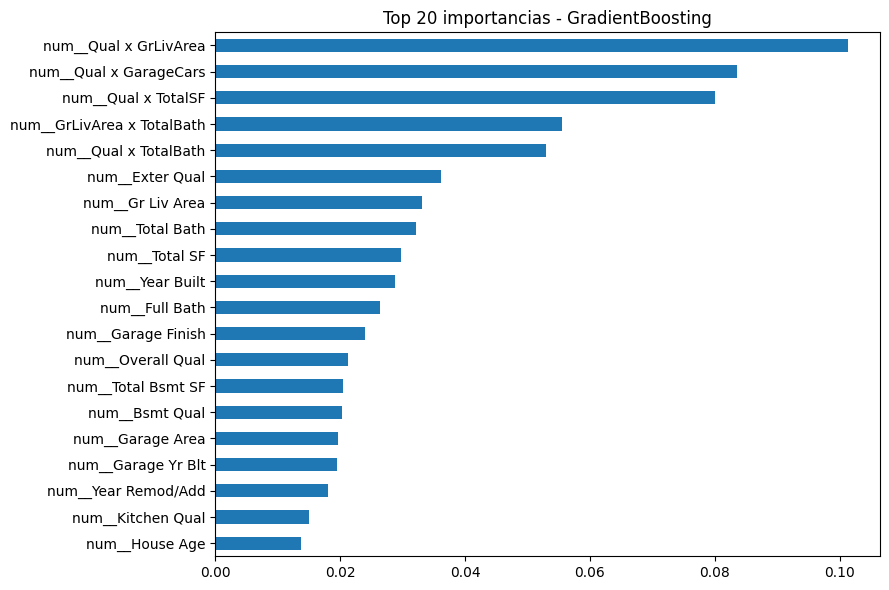


Modelo guardado: artifacts/best_model_pipeline.pkl


In [29]:
# ── Stacking Ensemble (combina los mejores modelos) ──────────────────────────
print('Entrenando Stacking Ensemble...')

# Recuperar los mejores hiperparámetros de cada modelo fuerte
best_gbr_params = {k.replace('model__', ''): v for k, v in search_gbr.best_params_.items()}
best_rf_params  = {k.replace('model__', ''): v for k, v in search_rf.best_params_.items()}
best_hgbr_params = {k.replace('model__', ''): v for k, v in search_hgbr.best_params_.items()}
best_ridge_alpha = grid_ridge.best_params_.get('model__alpha', 1.0)

stacking = StackingRegressor(
    estimators=[
        ('gbr',  Pipeline([('preprocessor', preprocessor),
                            ('model', GradientBoostingRegressor(**best_gbr_params, random_state=RANDOM_STATE))])),
        ('hgbr', Pipeline([('preprocessor', preprocessor),
                            ('model', HistGradientBoostingRegressor(**best_hgbr_params, random_state=RANDOM_STATE))])),
        ('rf',   Pipeline([('preprocessor', preprocessor),
                            ('model', RandomForestRegressor(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1))])),
    ],
    final_estimator=Ridge(alpha=best_ridge_alpha),
    cv=5, n_jobs=-1
)

stacking.fit(X_train, y_train)

y_val_pred_stack = np.expm1(stacking.predict(X_val))
stack_mse, stack_rmse, stack_mae, stack_r2 = compute_metrics(y_val, y_val_pred_stack)

print(f'Stacking → VAL_MSE = {stack_mse:,.2f}  VAL_RMSE = {stack_rmse:,.2f}  R² = {stack_r2:.4f}')

# ── Comparar stacking vs mejor individual ────────────────────────────────────
individual_mse = results.loc[0, 'VAL_MSE']
print(f'\nMejor individual ({best_model_name}): VAL_MSE = {individual_mse:,.2f}')
print(f'Stacking Ensemble:                     VAL_MSE = {stack_mse:,.2f}')

if stack_mse < individual_mse:
    print('✓ Stacking gana → se usa como modelo final')
    final_model = stacking
    final_model_name = 'StackingEnsemble'
    final_mse = stack_mse
else:
    print(f'✓ {best_model_name} individual gana → se usa como modelo final')
    final_model = best_model
    final_model_name = best_model_name
    final_mse = individual_mse

print(f'\n★ Modelo final: {final_model_name} con VAL_MSE = {final_mse:,.2f}')

# ── Feature importances (si aplica) ─────────────────────────────────────────
if final_model_name != 'StackingEnsemble' and hasattr(final_model.named_steps.get('model', None), 'feature_importances_'):
    feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
    importances = final_model.named_steps['model'].feature_importances_
    imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print('\nTop 20 importancias de variables:')
    display(imp_series.head(20))

    plt.figure(figsize=(9, 6))
    imp_series.head(20).sort_values().plot(kind='barh')
    plt.title(f'Top 20 importancias - {final_model_name}')
    plt.tight_layout()
    plt.show()

# ── Guardar artefacto ────────────────────────────────────────────────────────
model_artifact = {
    'model_name': final_model_name,
    'pipeline': final_model,
    'features_used': X.columns.tolist(),
    'cols_to_drop_training': cols_to_drop_training,
    'redundant_cols': redundant_cols,
    'random_state': RANDOM_STATE,
}

os.makedirs('artifacts', exist_ok=True)
model_path = 'artifacts/best_model_pipeline.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_artifact, f)
print(f'\nModelo guardado: {model_path}')

In [31]:
import os
import pickle
import pandas as pd
import numpy as np

test_path = 'data/test_features.csv'
model_path = 'artifacts/best_model_pipeline.pkl'
output_path = 'predicciones.csv'

if not os.path.exists(test_path):
    print('Aún no existe data/test_features.csv.')
elif not os.path.exists(model_path):
    print('No existe artifacts/best_model_pipeline.pkl. Ejecuta primero el entrenamiento.')
else:
    with open(model_path, 'rb') as f:
        artifact = pickle.load(f)

    # Restaurar globals necesarios para preparar_datos
    cols_to_drop_training = artifact.get('cols_to_drop_training', [])
    redundant_cols_loaded = artifact.get('redundant_cols', [])

    X_test = pd.read_csv(test_path)
    X_test = preparar_datos(X_test)

    model = artifact['pipeline']
    expected_features = artifact['features_used']

    missing_cols = [c for c in expected_features if c not in X_test.columns]
    if missing_cols:
        print(f'⚠ Columnas faltantes en test (se agregarán con 0): {missing_cols}')
        for c in missing_cols:
            X_test[c] = 0

    X_test = X_test[expected_features]

    pred_log = model.predict(X_test)
    pred_original_scale = np.expm1(pred_log)

    # Clamp para evitar predicciones negativas
    pred_original_scale = np.maximum(pred_original_scale, 0)

    submission = pd.DataFrame({'SalePrice': pred_original_scale})
    submission.to_csv(output_path, index=False)

    assert list(submission.columns) == ['SalePrice'], 'La columna debe llamarse SalePrice'
    assert submission.shape[1] == 1, 'Debe haber exactamente una sola columna'
    assert len(submission) == len(pd.read_csv(test_path)), 'El número de filas no coincide'
    assert submission['SalePrice'].isna().sum() == 0, 'Hay valores faltantes en predicciones'

    print(f'predicciones.csv generado: {submission.shape}')
    print(submission.describe())

predicciones.csv generado: (586, 1)
           SalePrice
count     586.000000
mean   187762.483530
std     83258.614738
min     36755.998068
25%    131172.159834
50%    166917.889944
75%    227801.997571
max    520719.448541
